**Tabla de contenido**
- [Lectura de datos](#Lectura-de-datos)
- [Exploración de datos](#Exploracion-de-datos)
    - [Resumen exploración de datos](#Resumen-analisis-exploratorio)
- [Preprocesamiento](#Preprocesamiento)
- [Modelado](#Modelado)
- [Evaluación](#Evaluacion)

En este cuaderno se entrena un red neuronal para predecir el cancer de mama. Este problema se divide en las siguientes etapas:

1. Exploración de los datos
2. Preprocesamiento
3. Modelado

# Lectura de datos

In [1]:
import pandas as pd
import os

import matplotlib.pyplot as plt

file_path = lambda file: os.path.join(os.getcwd(),'data/cancer mama r',file)
df = pd.read_csv(file_path('Cancer_Data.csv'))
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Exploracion de datos

En la exploración de datos vamos a revisar lo siguiente:
1. Cantida de registros del dataset
2. Tipos de variables que hay en el dataset
3. Cantida de valores nulos y valores dúplicados
4. detección de valores atípicos
5. Análisis de balanceo de clases
6. Correlaciones

In [2]:
#1. 
df.shape

(569, 33)

Tenemos 569 registros y 33 características.

In [3]:
# 2.
print(f"Cantidad de columnas tipo object: {df.select_dtypes(include=['object']).shape[1]}")
print(f"Cantidad de columnas numéricas: {df.select_dtypes(include=['number']).shape[1]}")

Cantidad de columnas tipo object: 1
Cantidad de columnas numéricas: 32


Veamos cual es la columna de tipo objet

In [4]:
df.select_dtypes(include=['object']).head(2)

,diagnosis
0,M
1,M


Aqui, podemos observar que la variable objetivo `Diagnosis` es la que está en formato texto, por lo cual está variable la codificaremos más adelante.

Veamos ahora la cantidad de valores faltantes que hay, y la cantidad de registros dúplicados.

In [5]:
# 3
nulos = {col: df[col].isnull().sum() for col in df.columns} 
nulos = pd.DataFrame.from_dict(nulos,orient='index',columns=['nulos'])
nulos.head(len(nulos))


,nulos
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Podemos observar que la columna Unnamed: 32 contiene 569 registros nulos, y el dataframe contiene un total de 569 registros, esto indica que esta columna la podemos eliminar.

In [6]:
df = df.drop(columns=['Unnamed: 32','id'], axis=1)

Ahora consultemos los valores dúpicados

In [7]:
duplicados = df[df.duplicated(keep=False)] # incluye la primera aparición
duplicados.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst


Por lo visto, no tenemos valores dúplicados. Veamos ahora los valores atípicos.

In [8]:
import plotly.graph_objects as go
import plotly.colors as pc
import plotly.express as px

target = df['diagnosis']
features = df.drop(columns=['diagnosis'], axis=1)

def plot_boxplots(df, title='Boxplots por variable', height=300):
    """
    Genera un boxplot interactivo con colores variados para cada columna numérica del DataFrame.

    Parámetros:
    - df: pandas.DataFrame con los datos
    - title: título del gráfico
    - height: altura del gráfico en píxeles
    """
    fig = go.Figure()

    numeric_cols = df.select_dtypes(include='number').columns
    colors = pc.qualitative.Plotly  # paleta de colores categóricos

    for i, column in enumerate(numeric_cols):
        fig.add_trace(go.Box(
            y=df[column],
            name=column,
            boxpoints='outliers',
            marker=dict(size=4, color=colors[i % len(colors)]),
            line=dict(color=colors[i % len(colors)]),
            fillcolor=colors[i % len(colors)],
        ))

    fig.update_layout(
        title=title,
        yaxis_title='Valor',
        boxmode='group',
        template='plotly_white',
        font=dict(family='Arial', size=14),
        margin=dict(l=40, r=40, t=60, b=40),
        height=height,
        showlegend=False,
    )

    fig.show()

plot_boxplots(features, title='Distribución de variables numéricas', height=300)

Podemos observar que el `area_mean`, `area_se` y `area_worst` tienen escalas muy amplias en comparación con el resto de características, esto indica:
1. Es necesario que los datos se escalen.
2. Hay características con muchos valores atípicos, pero no serán eliminados por que pueden aportar valor a la clasificación.

Veamos ahora si las clases están balanceadas.

In [9]:
#5
unicos = target.value_counts(normalize=True)*100
print(unicos)


diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


Podemos ver que la clase con más registros es la clase `B` que significa cancer benigno. Veamos ahora las correlaciones

<Axes: >

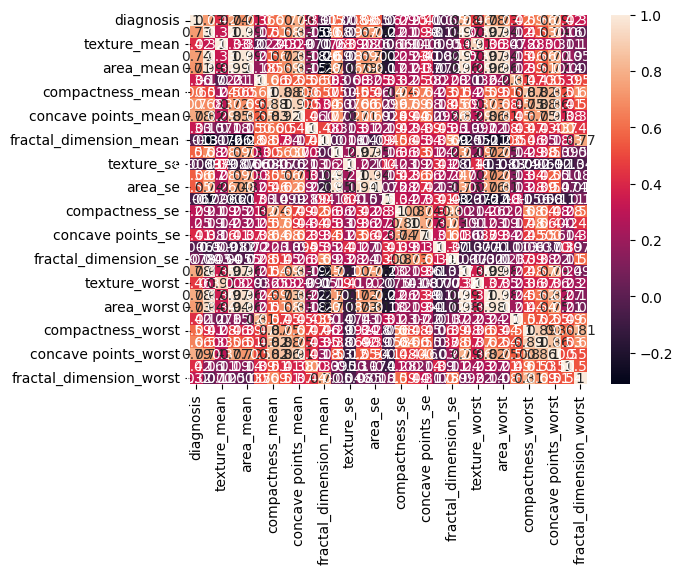

In [10]:
# 6
import seaborn as sns
dicc = {
    'B':0,
    'M':1
}
df['diagnosis'] = df['diagnosis'].map(dicc)
correl = df.corr()
sns.heatmap(correl, annot=True)

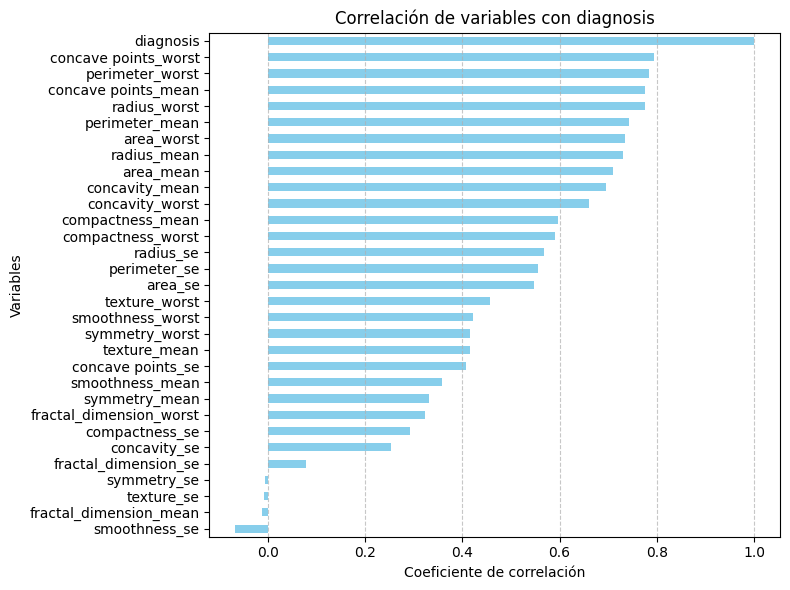

In [11]:
correlacionadas = correl.loc['diagnosis']
correlacionadas = correlacionadas.sort_values(ascending=True)
plt.figure(figsize=(8, 6))
correlacionadas.plot(kind='barh', color='skyblue')
plt.title('Correlación de variables con diagnosis')
plt.xlabel('Coeficiente de correlación')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Podemos ver, que hay muchas variables correlacionadas con la variable objetivo `diagnosis`.

## Resumen analisis exploratorio

Los resultados encontrados en el análisis explorario fueron los siguientes:

- Hay un total de 569 registros y 33 características.
- Es necesario que los datos se escalen ya que hay características con muchos valores atípicos, pero no serán eliminados por que pueden aportar valor a la clasificación.
- La columna objetivo tiene 2 clases  y estan desbalanceadas
- Muchas de las características estan altamente correlacionadas con la variable objetivo.

# Preprocesamiento

En esta etapa del preprocesamiento se realizaran las siguientes tranformaciones:

- La variable objetivo debemos convertilar a un array de dimención [m, 1]
- `Scalar los datos`: Usaré un MinMaxScaler para escalar los datos a un rango de 0 a 1, ya que a las redes neuronales se les facilita tratar con esta escala.
- Dividir los datos en entrenamiento, validación y prueba.

In [12]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

target = target.map(dicc)
target = target.to_numpy().reshape(-1,1) # convierte la forma [m,1]
escalador = MinMaxScaler()
featuresM = escalador.fit_transform(features) # escala los datos
X_train,_X_test,Y_train,Y_test = train_test_split(featuresM,target,test_size=0.1,random_state=42,shuffle=True)

# Modelado

Vamos a crear un función que es la encargada de entrenar el modelo

In [13]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam

def compilar_y_entrenar(model,patience = 100, max_epochs=500):
    early_stop = EarlyStopping(
    monitor='val_accuracy',  
    patience=patience,
    restore_best_weights=True,
    mode='max'  # Maximizar accuracy
    )
    # compila el modelo
    model.compile(
        loss = "sparse_categorical_crossentropy",  # Para etiquetas enteras
        optimizer = "sgd",  
        metrics = ['accuracy']
    )

    # Entrena el modelo
    history = model.fit(
        x =X_train,
        y =Y_train,
        validation_split=0.05,  # 5% de X_train para validación
        epochs = max_epochs,
        callbacks=[early_stop]
    )
    return history

2025-07-31 11:38:17.131864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753979897.150253  130237 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753979897.155669  130237 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753979897.168599  130237 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753979897.168625  130237 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753979897.168628  130237 computation_placer.cc:177] computation placer alr

Ahora lo que realizaremos será la creación del modelo de clasificación binaria, el cual lo aremos con los siguientes parámetros:

-  `función de activación para capas internas`: Relu, esta función devuelve cero si la entrada es negativa y devuelve el mismo valor si la entrada en positiva. Esta función no tiene problemas de saturación, haciendo que el algoritmo del gradiente descendente converga rapidamente, facilitando así el entrenamiento.
- `Función de activación para capa de salida`: Sigmoide, ya que mapea los datos de entrada a una salida binaria, que es lo que necesitamos en este caso.

In [14]:
tf.keras.backend.clear_session() # reiniciar el kernel
model = Sequential([
    Dense(units=8, activation='relu'),
    Dropout(0.5),
    Dense(units=2, activation='softmax')  # 2 neuronas para 2 clases
])

I0000 00:00:1753979898.926143  130237 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6203 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Ahora si procedamos a compilar el modelo y entrenarlo.

Epoch 1/500


I0000 00:00:1753979899.415985  132016 service.cc:152] XLA service 0x774a14005120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753979899.416009  132016 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 with Max-Q Design, Compute Capability 7.5
2025-07-31 11:38:19.429109: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753979899.472390  132016 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5000 - loss: 0.6756

I0000 00:00:1753979900.213068  132016 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5695 - loss: 0.6659 - val_accuracy: 0.5385 - val_loss: 0.6476
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5738 - loss: 0.6671 - val_accuracy: 0.6538 - val_loss: 0.6377
Epoch 3/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6161 - loss: 0.6502 - val_accuracy: 0.6923 - val_loss: 0.6289
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6242 - loss: 0.6568 - val_accuracy: 0.7308 - val_loss: 0.6200
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7084 - loss: 0.6241 - val_accuracy: 0.7308 - val_loss: 0.6122
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6502 - loss: 0.6519 - val_accuracy: 0.7308 - val_loss: 0.6063
Epoch 7/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7211 - loss: 0.6115 - val_accuracy: 0.7308 - val_loss: 0.5979
Epoch 8/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7185 - loss: 0.6088 - val_accuracy: 0.7308 - val_loss: 0.

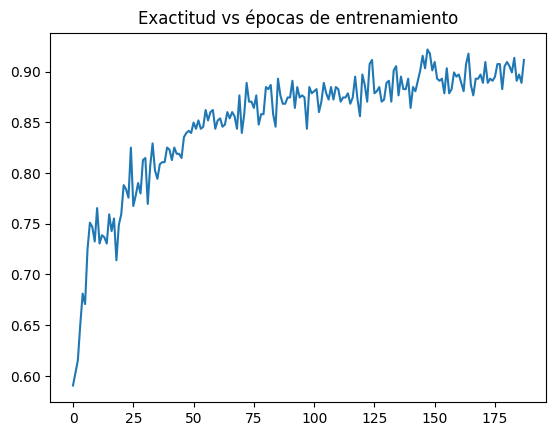

In [15]:
historial = compilar_y_entrenar(model)
historial.history.keys()
# convirtiendo historia a pandas
historia_Epoca= pd.DataFrame(historial.history)
# graficando exactitud vs época
plt.plot(historial.history["accuracy"])
plt.title("Exactitud vs épocas de entrenamiento");

# Evaluacion

Ahora que ya tenemos el modelo entrenado, procedemos a evaluarlo con los datos de test.

In [16]:
scores = pd.DataFrame([model.evaluate(_X_test, Y_test)],
                      columns =model.metrics_names)
scores.head()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9220 - loss: 0.2321


,loss,compile_metrics
0,0.227321,0.929825


Sabemos que el modelo tiene una precisión del 94%, pero veamos la matrix de confusión.

In [ ]:
from sklearn.metrics import confusion_matrix

probabilidades = model.predict(_X_test) # obtener la probabilidad
# Obtener la clase predicha (la de mayor probabilidad)
predicciones_clases = np.argmax(probabilidades, axis=1)  # Ej: [0, 1, 1, 0]
print(predicciones_clases)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[0 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]


In [20]:
import plotly.figure_factory as ff
cm = confusion_matrix(Y_test, predicciones_clases, labels=[1, 0])  # 1 = positivo, 0 = negativo
# Extraer valores
VP, FN = cm[0][0], cm[0][1]
FP, VN = cm[1][0], cm[1][1]

# Texto con etiquetas + valores
annotations = [
    [f'VP = {VP}', f'FN = {FN}'],
    [f'FP = {FP}', f'VN = {VN}']
]

# Crear el heatmap
fig = ff.create_annotated_heatmap(
    z=cm,
    x=['Predicho: Positivo', 'Predicho: Negativo'],
    y=['Real: Positivo', 'Real: Negativo'],
    annotation_text=annotations,
    colorscale='Blues',
    showscale=True
)

fig.update_layout(
    title='Matriz de Confusión con Etiquetas y Valores',
    xaxis_title='Predicción del Modelo',
    yaxis_title='Estado Real',
    autosize=True
)

fig.show()